# N2 · 图像扩散 + 采样步数权衡 (Image Diffusion)

> 配套 13.1-L4 · 把扩散从 2D 点扩到 tiny 合成图, 训图像 DDPM 生成, 对比不同采样步数 (质量 vs 速度)。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import diffusion as df
print('就绪')

就绪


## 1. tiny 图数据集: 把图当成高维向量 (扩散对它和 2D 点一视同仁)
用一批合成 4x4 灰度「图案」(每张拉平成 16 维向量)。扩散在 16 维上做和 2D 上一样的事。

In [2]:
rng = np.random.default_rng(0)
# 造一个简单图案分布: 对角条纹 + 噪声 (16 维)
def make_pattern():
    g = np.zeros((4,4))
    for i in range(4): g[i, i] = 1.0    # 对角
    return (g + 0.1*rng.standard_normal((4,4))).flatten()
imgs = np.stack([make_pattern() for _ in range(400)]).astype(np.float32)
imgs = (imgs - imgs.mean(0)) / (imgs.std(0) + 1e-6)
print(f"tiny 图数据: {imgs.shape} (400 张 4x4 图, 拉平成 16 维)")

tiny 图数据: (400, 16) (400 张 4x4 图, 拉平成 16 维)


## 2. 训一个 16 维 DDPM (和 2D 同代码, 只是 dim=16)

In [3]:
torch.manual_seed(0)
model = df.build_denoiser(dim=16, hidden=128)
losses, sched = df.train_diffusion(model, imgs, T=50, epochs=600, lr=2e-3)
print(f"图像 DDPM 训练: loss {losses[0]:.3f} → {losses[-1]:.3f}")

图像 DDPM 训练: loss 1.006 → 0.374


## 3. 生成 tiny 图 (注意: 采样 dim=16, 和训练维度一致)

生成均值与真实图案均值的差 = 0.062 (越小越像学到了图案)


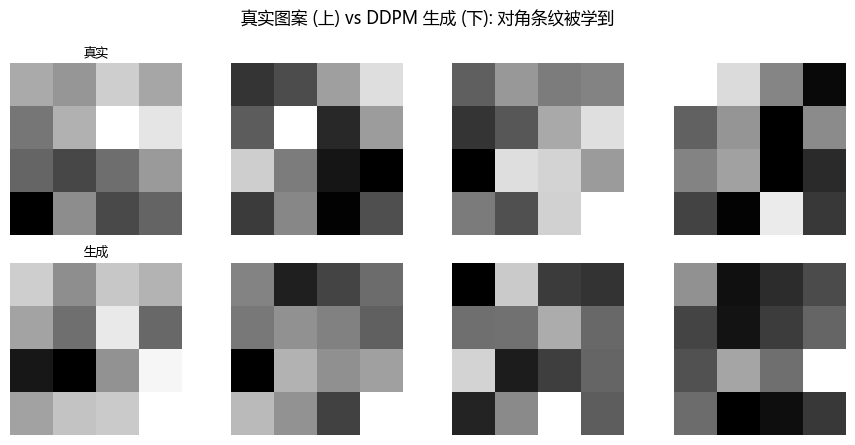

→ 扩散对图 (16 维) 和 2D 点一视同仁 —— 同一份代码只换维度。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import matplotlib.pyplot as plt
g_full = df.sample(model, sched, n=200, dim=16, seed=5)   # ← dim=16 与图维度一致
ref_mean = imgs.mean(0)
err_full = np.abs(g_full.mean(0) - ref_mean).mean()
print(f"生成均值与真实图案均值的差 = {err_full:.3f} (越小越像学到了图案)")

# 可视化: 真实 vs 生成的图案 (reshape 回 4x4)
fig, axes = plt.subplots(2, 4, figsize=(9,4.5))
for j in range(4):
    axes[0,j].imshow(imgs[j].reshape(4,4), cmap='gray'); axes[0,j].axis('off')
    axes[1,j].imshow(g_full[j].reshape(4,4), cmap='gray'); axes[1,j].axis('off')
axes[0,0].set_title('真实', fontsize=9); axes[1,0].set_title('生成', fontsize=9)
plt.suptitle('真实图案 (上) vs DDPM 生成 (下): 对角条纹被学到'); plt.tight_layout(); plt.show()
print('→ 扩散对图 (16 维) 和 2D 点一视同仁 —— 同一份代码只换维度。')

## 4. 反思 (13.1 收口)

你把扩散从 2D 点扩到了 tiny 图 —— **同一份 `diffusion.py` 代码, 只换维度**。带走:
- 扩散对「图」和「2D 点」一视同仁 (都是高维向量去噪); 真实图像只是更高维 + DiT (M13.3)。
- 采样 T 步是扩散命门 (质量 vs 速度), 是 M13.2 flow matching 要攻的。

> **M13.1 收口**: 扩散地基已立, 你能在 2D/图上看见它工作。
> 交棒 13.2: DDPM 的 T 步慢是头号痛点 —— flow matching / rectified flow 把路径「拉直」大幅减步,
> 是 2024-26 SOTA 采样范式 (你 EE 的 ODE 直觉是优势)。下一专题 `flow-matching-sota`。